## KMeans on Iris Dataset


In [29]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

In [30]:
iris = load_iris()

In [31]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [32]:
X = iris.data
y = iris.target

<Axes: >

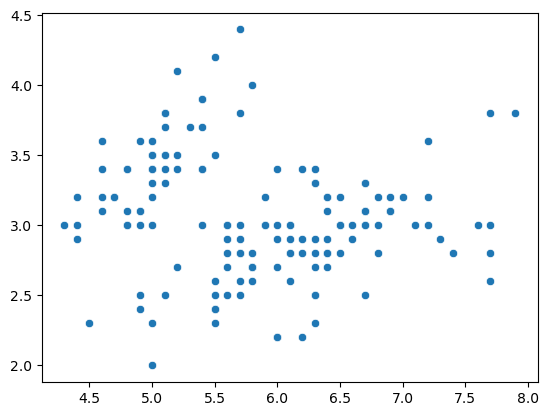

In [33]:
sns.scatterplot(x = X[:,0], y = X[:,1])

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X) 

In [35]:
# ELBOW METHOD

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(scaled_X)
    wcss.append(kmeans.inertia_)

d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

<Axes: >

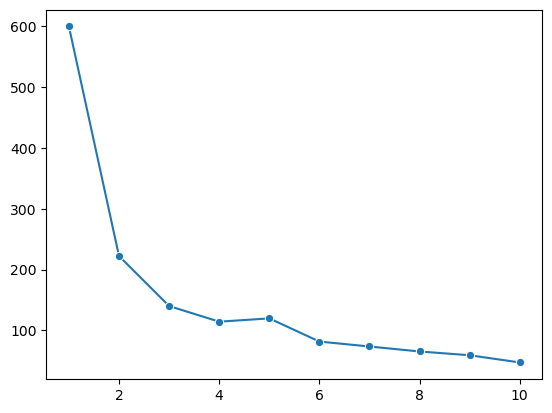

In [36]:
sns.lineplot(x = range(1,11), y = wcss, marker = "o")

d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Text(0.5, 1.0, 'Predicted clusters')

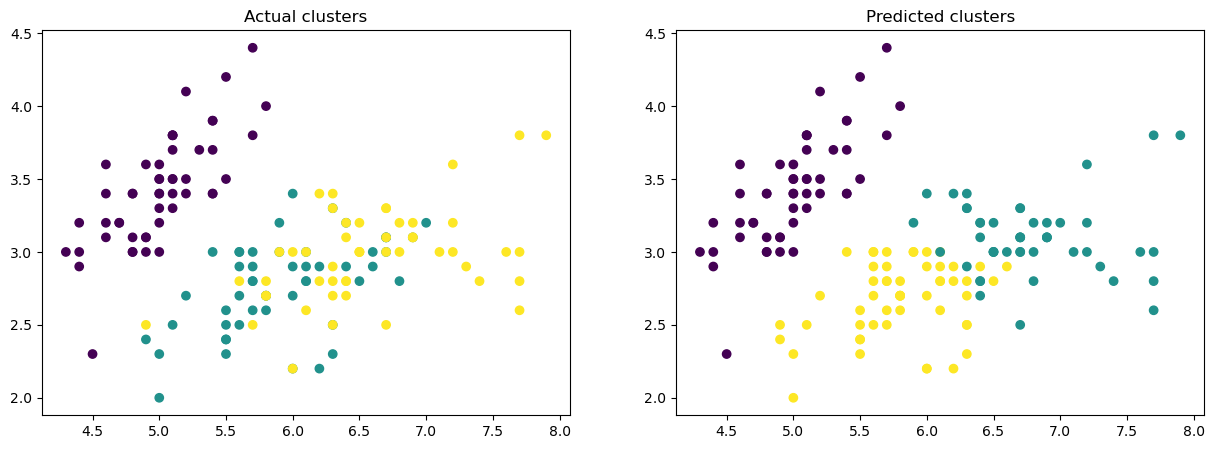

In [37]:
## Visualization after predicting by kmeans

import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,2,figsize = (15,5))

km = KMeans(n_clusters=3)
without_pca_labels = km.fit_predict(scaled_X)

ax[0].scatter(x = X[:,0], y = X[:,1],c = y)
ax[0].set_title("Actual clusters")

ax[1].scatter(x = X[:,0], y = X[:,1],c = without_pca_labels)
ax[1].set_title("Predicted clusters")

In [38]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_X = pca.fit_transform(scaled_X)

d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Text(0.5, 1.0, 'After applying PCA')

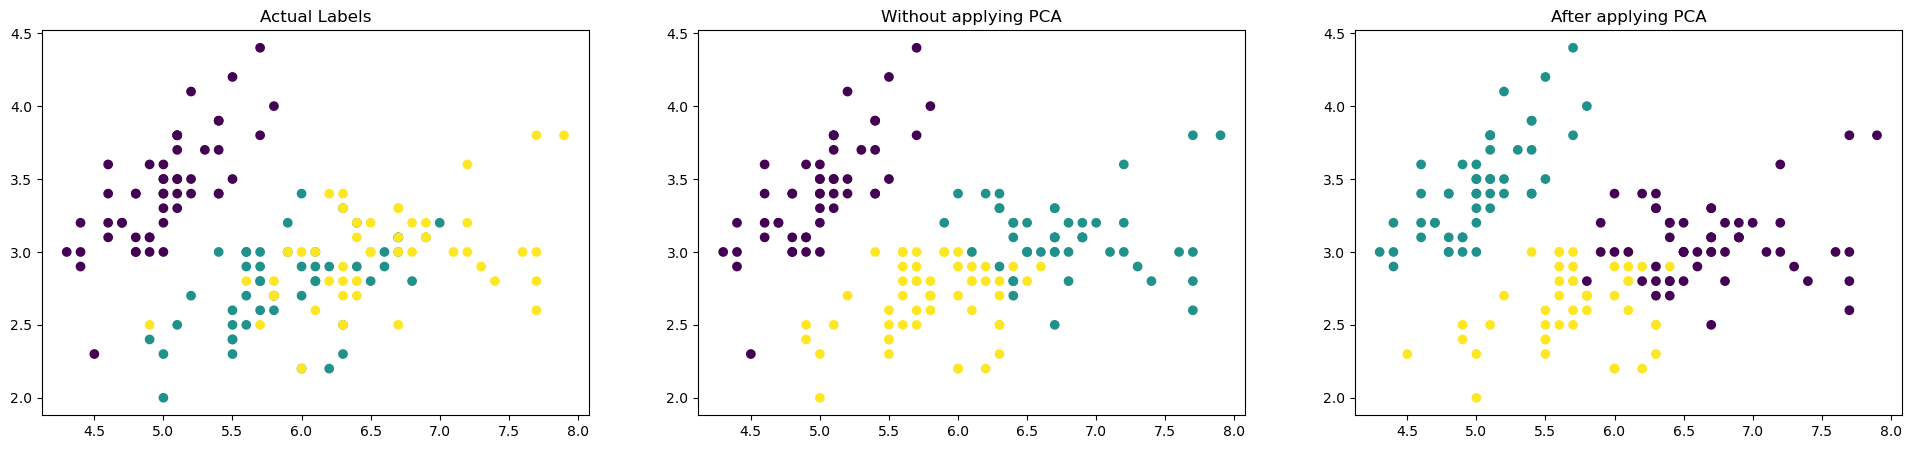

In [ ]:
## Visualization after using PCA

import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,3,figsize = (24,5))

km = KMeans(n_clusters=3)
after_pca_labels = km.fit_predict(pca_X)

ax[0].scatter(x = X[:,0], y = X[:,1],c = y)
ax[0].set_title("Actual Labels")

ax[1].scatter(x = X[:,0], y = X[:,1],c = without_pca_labels)
ax[1].set_title("Without applying PCA")

ax[2].scatter(x = X[:,0], y = X[:,1],c = after_pca_labels)
ax[2].set_title("After applying PCA")